In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering



In [4]:
df = pd.read_csv("/yellow_tripdata_2015-01.csv")
df.shape

(6704243, 19)

In [4]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RateCodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount',
       'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'total_amount'],
      dtype='object')

In [5]:
df.sample(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
1162323,2,2015-01-12 15:12:19,2015-01-12 15:27:15,1.0,1.65,-73.982872,40.745022,1.0,N,-74.005676,40.743549,1.0,10.5,0.0,0.5,2.10,0.0,0.3,13.40
1323539,1,2015-01-18 12:11:47,2015-01-18 12:19:25,2.0,2.00,-73.995667,40.759422,1.0,N,-73.968773,40.762363,1.0,8.0,0.0,0.5,1.75,0.0,0.3,10.55
6369209,2,2015-01-22 18:28:19,2015-01-22 18:30:11,1.0,0.34,-73.986755,40.761181,1.0,N,-73.983910,40.765285,2.0,3.5,1.0,0.5,0.00,0.0,0.3,5.30
4839184,2,2015-01-14 08:47:18,2015-01-14 08:57:19,2.0,1.44,-73.971809,40.794407,1.0,N,-73.962418,40.804821,2.0,8.5,0.0,0.5,0.00,0.0,0.3,9.30
6898,2,2015-01-18 23:36:58,2015-01-18 23:39:25,1.0,0.78,-73.989403,40.763058,1.0,N,-73.997131,40.756226,2.0,4.5,0.5,0.5,0.00,0.0,0.3,5.80


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704243 entries, 0 to 6704242
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             float64
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           float64
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(15), int64(1), object(3)
memory usage: 971.8+ MB


In [7]:
df.describe()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,6.704243e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06,6.704242e+06
mean,1.521240e+00,1.680403e+00,1.382839e+01,-7.256036e+01,3.997195e+01,1.036522e+00,-7.260800e+01,3.999909e+01,1.386261e+00,1.190841e+01,3.089859e-01,4.978060e-01,1.546027e+00,2.435378e-01,2.836069e-01,1.480403e+01
std,4.995487e-01,1.336911e+00,1.094165e+04,1.013048e+01,5.580674e+00,6.443292e-01,9.967651e+00,5.489191e+00,4.986115e-01,1.029170e+01,7.177143e-01,3.527494e-02,2.412199e+00,1.599249e+00,6.818508e-02,1.255592e+01
min,1.000000e+00,0.000000e+00,0.000000e+00,-1.219258e+02,0.000000e+00,1.000000e+00,-7.364167e+02,-9.029157e+00,1.000000e+00,-4.500000e+02,-2.000000e+00,-5.000000e-01,-9.242000e+01,-2.600000e+01,0.000000e+00,-4.503000e+02
25%,1.000000e+00,1.000000e+00,1.000000e+00,-7.399169e+01,4.073554e+01,1.000000e+00,-7.399120e+01,4.073437e+01,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.190000e+00
50%,2.000000e+00,1.000000e+00,1.670000e+00,-7.398161e+01,4.075316e+01,1.000000e+00,-7.397977e+01,4.075363e+01,1.000000e+00,9.000000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,3.000000e-01,1.116000e+01
75%,2.000000e+00,2.000000e+00,3.000000e+00,-7.396665e+01,4.076758e+01,1.000000e+00,-7.396246e+01,4.076881e+01,2.000000e+00,1.350000e+01,5.000000e-01,5.000000e-01,2.070000e+00,0.000000e+00,3.000000e-01,1.630000e+01
max,2.000000e+00,9.000000e+00,1.542000e+07,7.866265e+01,5.695230e+01,9.900000e+01,8.527402e+01,4.048333e+02,5.000000e+00,3.005500e+03,9.999900e+02,5.000000e-01,8.500000e+02,1.450090e+03,3.000000e-01,3.006350e+03


In [5]:
df.duplicated().sum()

np.int64(170)

In [6]:
df.drop_duplicates(inplace = True)

In [7]:
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,1
trip_distance,1
pickup_longitude,1
pickup_latitude,1
RateCodeID,1
store_and_fwd_flag,1
dropoff_longitude,1


In [8]:
df.dropna(inplace = True)

In [12]:
df.shape

(6704072, 19)

In [13]:
df.head(5)
pd.set_option('display.max_rows', None)

In [9]:
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [10]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

In [16]:
df['passenger_count'].value_counts()

,count
passenger_count,
1.0,4731446
2.0,954141
5.0,366146
3.0,277451
6.0,238580
4.0,132804
0.0,3485
7.0,7
8.0,7


In [11]:
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

In [12]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek
df['is_weekend'] = df['pickup_day'].isin([5,6]).astype(int)

In [28]:
pd.set_option('display.max_columns', None)
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration,pickup_hour,pickup_day,is_weekend
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1.0,1.59,-73.993896,40.750111,1.0,N,-73.974785,40.750618,1.0,12.0,1.0,0.5,3.25,0.0,0.3,17.05,18.050000,19,3,0
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1.0,3.30,-74.001648,40.724243,1.0,N,-73.994415,40.759109,1.0,14.5,0.5,0.5,2.00,0.0,0.3,17.80,19.833333,20,5,1
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1.0,1.80,-73.963341,40.802788,1.0,N,-73.951820,40.824413,2.0,9.5,0.5,0.5,0.00,0.0,0.3,10.80,10.050000,20,5,1
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1.0,0.50,-74.009087,40.713818,1.0,N,-74.004326,40.719986,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,1.866667,20,5,1
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1.0,3.00,-73.971176,40.762428,1.0,N,-74.004181,40.742653,2.0,15.0,0.5,0.5,0.00,0.0,0.3,16.30,19.316667,20,5,1


In [13]:
features = df[[
    'trip_distance',
    'trip_duration',
    'total_amount',
    'pickup_hour',
    'passenger_count'
]]

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

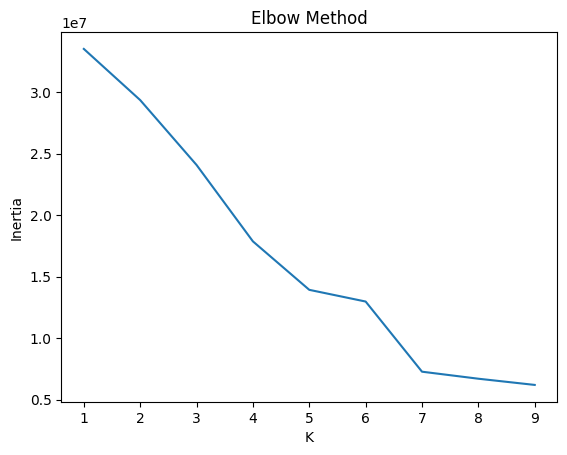

In [15]:
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [16]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['clusters'] = kmeans.fit_predict(scaled_features)

In [20]:
df.groupby('clusters').mean(numeric_only=True)

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration,pickup_hour,pickup_day,is_weekend
clusters,,,,,,,,,,,,,,,,,,,,
0,1.516329,1.517322,1.320450e+01,-72.034010,39.697823,1.487992,-72.060450,39.701706,1.256607,42.695989,0.215630,0.477798,6.340952,3.514085,0.281441,53.544220,51.865959,13.683505,3.101404,0.263673
1,1.460361,1.216729,2.924084e+00,-72.469336,39.920906,1.010023,-72.536542,39.959485,1.400369,10.019123,0.132371,0.498925,1.212096,0.028818,0.281855,12.190521,11.795107,7.701994,3.281358,0.320861
2,1.923114,5.150690,2.373759e+00,-73.328094,40.394547,1.001974,-73.318638,40.390768,1.400771,10.638780,0.314819,0.499287,1.290311,0.114068,0.293658,13.156228,13.263306,13.626078,3.310165,0.324242
3,1.000000,1.166667,1.113664e+07,-73.982340,40.753190,1.000000,-73.951781,40.730437,2.000000,15.416667,0.416667,0.500000,0.000000,0.000000,0.300000,16.633333,30.694444,18.333333,4.500000,0.333333
4,1.478873,1.278313,3.782377e+00,-72.529630,39.953798,1.008090,-72.576955,39.981581,1.387842,9.784371,0.468551,0.499124,1.262256,0.028403,0.283006,12.342048,11.842154,18.549133,3.212718,0.295404


In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

df['pca1'] = pca_features[:, 0]
df['pca2'] = pca_features[:, 1]

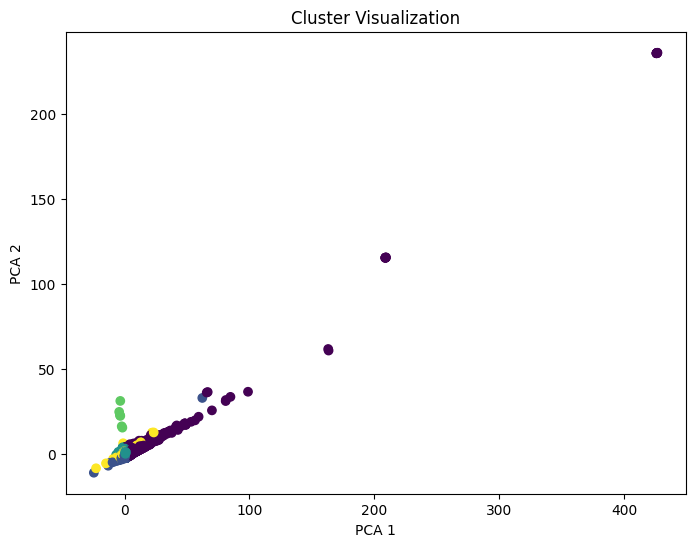

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(df['pca1'], df['pca2'], c=df['clusters'])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cluster Visualization")
plt.show()

In [23]:
df['clusters'].value_counts()

,count
clusters,
4,3037504
1,2558196
2,712394
0,395972
3,6


In [ ]:
df.head()

In [26]:
cluster_summary = df.groupby('clusters')[
    ['trip_distance', 'trip_duration', 'total_amount', 'pickup_hour', 'passenger_count']
].mean()

cluster_summary

,trip_distance,trip_duration,total_amount,pickup_hour,passenger_count
clusters,,,,,
0,1.320450e+01,51.865959,53.544220,13.683505,1.517322
1,2.924084e+00,11.795107,12.190521,7.701994,1.216729
2,2.373759e+00,13.263306,13.156228,13.626078,5.150690
3,1.113664e+07,30.694444,16.633333,18.333333,1.166667
4,3.782377e+00,11.842154,12.342048,18.549133,1.278313


In [31]:
df['pickup_hour'].value_counts( normalize = True).sort_index()*100

,proportion
pickup_hour,
0,3.688370
1,2.768407
2,2.055721
3,1.546031
4,1.083655
5,1.009237
6,2.005289
7,3.668875
8,4.349163


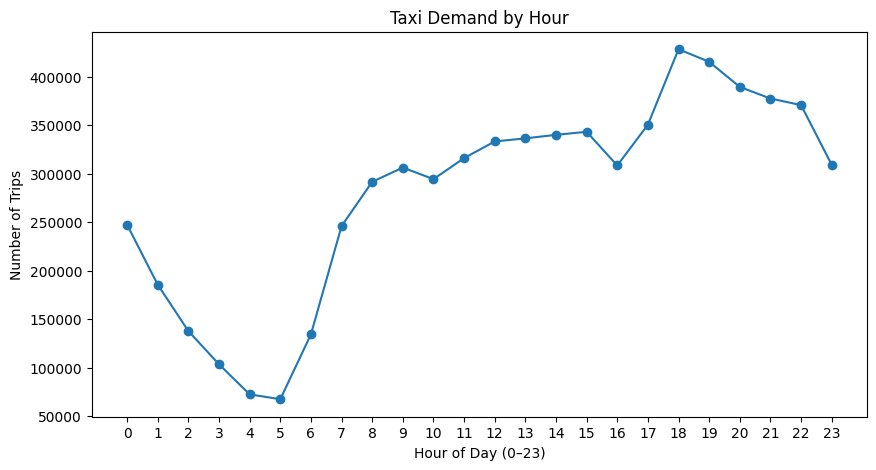

In [34]:

hourly_counts = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(hourly_counts.index, hourly_counts.values, marker='o')

plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23])

plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Trips")
plt.title("Taxi Demand by Hour")

plt.show()

In [37]:
df.groupby(['pickup_hour', 'clusters']).size().unstack()

clusters,0,1,2,3,4
pickup_hour,,,,,
0,10763.0,208661.0,27847.0,NaN,NaN
1,6604.0,158275.0,20717.0,NaN,NaN
2,4649.0,117826.0,15342.0,NaN,NaN
3,4417.0,87153.0,12077.0,NaN,NaN
4,5800.0,58848.0,8001.0,NaN,NaN
5,9887.0,51766.0,6007.0,NaN,NaN
6,13015.0,109663.0,11758.0,NaN,NaN
7,14904.0,207676.0,23384.0,NaN,NaN
8,14238.0,247128.0,30205.0,NaN,NaN


In [40]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,...,tolls_amount,improvement_surcharge,total_amount,trip_duration,pickup_hour,pickup_day,is_weekend,clusters,pca1,pca2
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1.0,1.59,-73.993896,40.750111,1.0,N,-73.974785,...,0.0,0.3,17.05,18.050000,19,3,0,4,-0.235907,0.141674
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1.0,3.30,-74.001648,40.724243,1.0,N,-73.994415,...,0.0,0.3,17.80,19.833333,20,5,1,4,-0.269144,0.244384
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1.0,1.80,-73.963341,40.802788,1.0,N,-73.951820,...,0.0,0.3,10.80,10.050000,20,5,1,4,-0.659130,0.096073
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1.0,0.50,-74.009087,40.713818,1.0,N,-74.004326,...,0.0,0.3,4.80,1.866667,20,5,1,4,-0.993246,-0.030964
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1.0,3.00,-73.971176,40.762428,1.0,N,-74.004181,...,0.0,0.3,16.30,19.316667,20,5,1,4,-0.351485,0.213282


In [41]:
pivot = df.groupby(['pickup_day', 'pickup_hour']).size().unstack()
pivot

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_day,,,,,,,,,,,,,,,,,,,,,
0,16608,10090,8764,6573,5917,10007,19358,35438,39049,37820,...,42570,38722,34194,35125,42085,39417,37390,34918,24942,20932
1,12941,8203,4329,4100,4088,6699,18310,32715,40937,36785,...,35744,39852,37893,43841,57049,51492,52289,47832,43987,32056
2,19120,9396,9590,5522,3700,10281,25729,46578,52874,47673,...,42468,45871,33949,44019,59623,58445,56946,57273,53740,35290
3,39203,27593,22073,16991,17093,12833,27585,52236,60694,54108,...,56016,54546,47784,55933,74311,73591,62394,70776,69343,50819
4,35641,23188,15880,11162,6267,12383,23591,48505,54901,58893,...,54600,59221,48952,61379,74118,74371,78611,71001,72391,74654
5,69117,59719,40811,30066,19406,7989,12480,18806,25625,43063,...,62697,63108,60719,64670,76972,78507,65304,65489,74244,72015
6,54641,47407,36370,29233,16178,7468,7383,11686,17491,27879,...,45848,41773,44881,45370,43969,39353,36389,30085,31952,23410


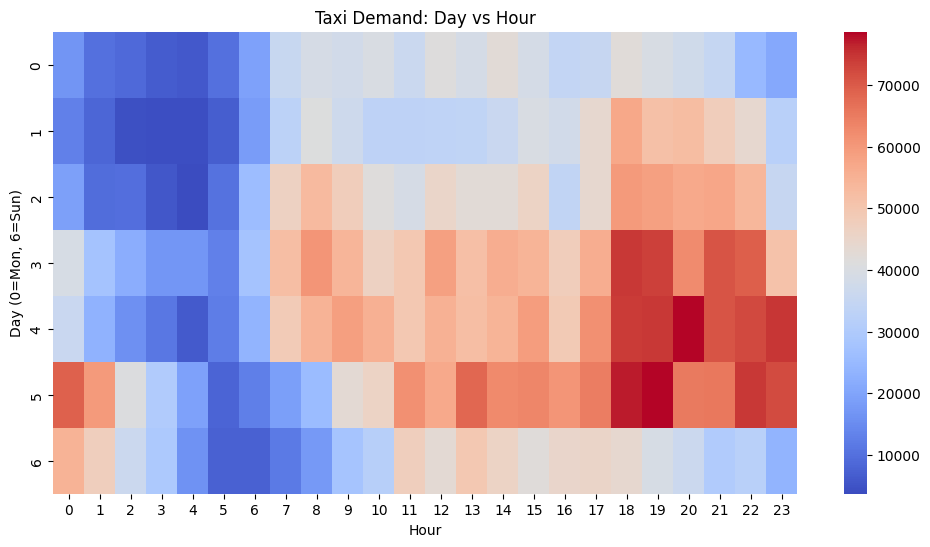

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Taxi Demand: Day vs Hour")
plt.xlabel("Hour")
plt.ylabel("Day (0=Mon, 6=Sun)")
plt.show()

In [43]:
df.groupby('pickup_day').size()

,0
pickup_day,
0,695634
1,744550
2,886125
3,1152505
4,1171746
5,1243131
6,810381


In [44]:
df.groupby('pickup_day')['pickup_hour'].count().sort_values()

,pickup_hour
pickup_day,
0,695634
1,744550
6,810381
2,886125
3,1152505
4,1171746
5,1243131
